In [55]:
!git stash
!git pull
!git stash pop

Saved working directory and index state WIP on main: 666b55d Fix response parsing
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 6 (delta 5), reused 6 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 1.19 KiB | 607.00 KiB/s, done.
From https://github.com/thowell332/llm-preferences
   666b55d..f9a0f17  main       -> origin/main
Updating 666b55d..f9a0f17
Fast-forward
 .../experiments/linear_probes/notebook_runs.py     | 94 ++++++++++++++++++++++
 1 file changed, 94 insertions(+)
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   .gitignore
	modified:   utility_analysis/experiments/linear_probes/results_linear_probes/llama-31-8b-instruct/linear_probes_llama-31-8b-instruct_full_multirole_X_ge

## Linear Probes Experiment Runner

This notebook runs the new `linear_probes` pipeline from `utility_analysis/experiments/linear_probes/run_linear_probes.py`.

Flow:
1. Configure model/options/roles/utilities
2. Run `linear_probes_collect` via `run_experiments.py`
3. Run `linear_probes_train` via `run_experiments.py`
4. Inspect and plot per-layer probe performance

In [1]:
COLAB_RUNTIME = True # Set to true to set up the experiment for a Google Colab runtime

In [19]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   .gitignore

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   utility_analysis/experiments/linear_probes/results_linear_probes/llama-31-8b-instruct/linear_probes_llama-31-8b-instruct_pilot_helpful_assistant_X_gen_first.pt
	modified:   utility_analysis/experiments/linear_probes/results_linear_probes/llama-31-8b-instruct/linear_probes_llama-31-8b-instruct_pilot_helpful_assistant_X_prompt_last.pt
	modified:   utility_analysis/experiments/linear_probes/results_linear_probes/llama-31-8b-instruct/linear_probes_llama-31-8b-instruct_pilot_helpful_assistant_layers.json
	modified:   utility_analysis/experiments/linear_probes/results_linear_probes/llama-31-8b-instruct/linear_probes_llama-31-8b-instruct_pilot_helpful_assist

In [14]:
from pathlib import Path

def clone_repo(
    repo_url: str,
    repo_root: Path,
    git_ref: str = "main"
) -> None:
    """Clone the repository into the Google Colab VM.

    Args:
        repo_url (str): The URL of the repository to clone.
        repo_root (Path): The root directory for installing the repository.
        git_ref (str): The branch or tag to checkout.
        force_clone (bool): If True, force the clone even if the repository already exists.
    """
    %cd {str(os.path.basename(repo_root))}
    if not repo_root.exists():
        !git clone {repo_url} {str(repo_root)}
    else:
        print("Repo already exists at:", repo_root)

    %cd {str(repo_root)}
    !git fetch --all -q
    !git reset --hard origin/{git_ref}

    assert (repo_root / "utility_analysis").exists(), (
        f"Expected utility_analysis/ under {repo_root}. "
    )

if COLAB_RUNTIME:
    REPO_URL = "https://github.com/thowell332/llm-preferences.git"
    REPO_ROOT = Path( "/content/llm_preferences").expanduser()

    clone_repo(REPO_URL, REPO_ROOT)

[Errno 2] No such file or directory: 'llm_preferences'
/content/llm_preferences
Repo already exists at: /content/llm_preferences
/content/llm_preferences
HEAD is now at 9f49927 Updapdate token parsing to accept two


In [3]:
%pip install --upgrade pip
%pip install -r /content/llm_preferences/requirements.txt "jedi>=0.16" "rich<14"

In [7]:
import os
import zipfile
from google.colab import drive
drive.mount('/content/drive')

MODEL_KEY = "llama-31-8b-instruct"
!mkdir -p /content/models/llama-31-8b-instruct
!rsync -r -progress /content/drive/MyDrive/llama-31-8b-instruct-quantized /content/models/llama-31-8b-instruct

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
MODELS_PATH = REPO_ROOT / "utility_analysis" / "models.yaml"

In [40]:
# --- Pilot: edit these ---
import sys
from pathlib import Path

import yaml
from transformers import AutoConfig
from IPython.display import display


NOTEBOOK_REPO_ROOT = REPO_ROOT if COLAB_RUNTIME else MODELS_PATH.parent.parent
LP_DIR = NOTEBOOK_REPO_ROOT / "utility_analysis" / "experiments" / "linear_probes"
if str(LP_DIR) not in sys.path:
    sys.path.insert(0, str(LP_DIR))

import importlib
import notebook_runs
importlib.reload(notebook_runs)

%matplotlib inline

if "MODEL_KEY" not in dir() or "MODELS_PATH" not in dir():
    raise RuntimeError("Run the model setup cell first (MODEL_KEY, MODELS_PATH).")

from notebook_runs import (
    default_utilities_rel,
    existing_probe_results_path,
    layer_indices,
    plot_probe_results_file,
    run_collect_then_train,
)

PILOT_ROLE = "helpful assistant"
PILOT_SAVE_DIR = f"results_linear_probes/{MODEL_KEY}"
PILOT_SAVE_SUFFIX = f"{MODEL_KEY}_pilot_{PILOT_ROLE}".replace(" ", "_")
OPTIONS_REL = "../../shared_options/options_custom.json"
UTILITIES_REL = None  # None -> default_utilities_rel(MODEL_KEY, PILOT_ROLE)

LAYER_MODE = "all"  # "sample" | "all"
NUM_SAMPLED_LAYERS = 16
MAX_EXAMPLES = 20
MAX_MODEL_LEN = 256
BACKEND = "vllm"
VLLM_NO_COMPILE = False
VLLM_ATTENTION_BACKEND = None  # e.g. "flash_attn"

POSITION = "gen_first"
TARGET = "utility"
PROBE_MODE = "all"
TEST_FRACTION = 0.2
SEED = 42
RIDGE_LAMBDA = 1.0

# Regenerate figure only (skip collect + train)
PILOT_PLOT_ONLY = False
# If True: set to a path string/Path, or None for default filename under PILOT_SAVE_DIR + PILOT_SAVE_SUFFIX.
PILOT_PROBE_RESULTS_JSON = None

if not PILOT_PLOT_ONLY:
    models_cfg = yaml.safe_load(MODELS_PATH.read_text())
    model_entry = models_cfg[MODEL_KEY]
    model_path = model_entry.get("path") or model_entry.get("model_name")
    if not model_path:
        raise ValueError(f"No path/model_name for {MODEL_KEY!r} in models.yaml")
    cfg = AutoConfig.from_pretrained(model_path, trust_remote_code=True)
    n_layers = int(cfg.num_hidden_layers)
    pilot_layers = layer_indices(LAYER_MODE, n_layers, NUM_SAMPLED_LAYERS)
    layers_spec = ",".join(str(x) for x in pilot_layers)
    utilities_rel = UTILITIES_REL or default_utilities_rel(MODEL_KEY, PILOT_ROLE)

    artifacts, results_path = run_collect_then_train(
        NOTEBOOK_REPO_ROOT,
        model_key=MODEL_KEY,
        save_dir=PILOT_SAVE_DIR,
        save_suffix=PILOT_SAVE_SUFFIX,
        options_path=OPTIONS_REL,
        utilities_path=utilities_rel,
        roles=PILOT_ROLE,
        layers=layers_spec,
        max_new_tokens_for_parsing=2,
        max_model_len=MAX_MODEL_LEN,
        max_examples=MAX_EXAMPLES,
        backend=BACKEND,
        position=POSITION,
        target=TARGET,
        probe_mode=PROBE_MODE,
        test_fraction=TEST_FRACTION,
        seed=SEED,
        ridge_lambda=RIDGE_LAMBDA,
        trust_remote_code=True,
        force_cpu=False,
        hf_fp16_cuda=True,
        hf_bnb_8bit=True,
        vllm_no_compile=VLLM_NO_COMPILE,
        vllm_attention_backend=VLLM_ATTENTION_BACKEND,
    )

    print("Saved artifacts (under linear_probes/):")
    for k, p in artifacts.items():
        print(f"  {k}: {p}")
    print("Probe metrics JSON:", results_path)
else:
    results_path = existing_probe_results_path(
        NOTEBOOK_REPO_ROOT,
        save_dir=PILOT_SAVE_DIR,
        save_suffix=PILOT_SAVE_SUFFIX,
        position=POSITION,
        target=TARGET,
        probe_mode=PROBE_MODE,
        explicit_path=PILOT_PROBE_RESULTS_JSON,
    )
    if not Path(results_path).is_file():
        raise FileNotFoundError(f"PILOT_PLOT_ONLY: missing probe results JSON: {results_path}")
    print("[PILOT_PLOT_ONLY] using existing:", results_path)


Running: /usr/bin/python3 -u /content/llm_preferences/utility_analysis/experiments/linear_probes/run_linear_probes.py --model_key llama-31-8b-instruct --stage collect --backend vllm --save_dir results_linear_probes/llama-31-8b-instruct --save_suffix llama-31-8b-instruct_pilot_helpful_assistant --options_path ../../shared_options/options_custom.json --utilities_path ../../shared_utilities/options_custom/llama-31-8b-instruct/results_utilities_llama-31-8b-instruct_helpful_assistant.json --roles helpful assistant --layers 0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31 --max_new_tokens_for_parsing 2 --max_model_len 256 --max_examples 20 --trust_remote_code
[collect:debug] ========== linear_probes collect ==========
[collect:debug] pid=10154 cwd=/content/llm_preferences/utility_analysis/experiments/linear_probes
[collect:debug] torch=2.10.0+cu128 cuda_available=True
[collect:debug] cuda_device_count=1
[collect:debug] model_path=/content/models/llama-31-

2026-04-14 12:32:10.979276: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-14 12:32:10.997943: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776169931.022456   10154 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776169931.029639   10154 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776169931.047021   10154 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Running: /usr/bin/python3 -u /content/llm_preferences/utility_analysis/experiments/linear_probes/run_linear_probes.py --model_key llama-31-8b-instruct --stage train --save_dir results_linear_probes/llama-31-8b-instruct --save_suffix llama-31-8b-instruct_pilot_helpful_assistant --position gen_first --target utility --probe_mode all --test_fraction 0.2 --ridge_lambda 1.0 --seed 42
[train] wrote probe metrics to results_linear_probes/llama-31-8b-instruct/linear_probes_llama-31-8b-instruct_pilot_helpful_assistant_probe_results_gen_first_utility_all.json


2026-04-14 12:33:01.645396: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-14 12:33:01.664891: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776169981.689493   10574 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776169981.696718   10574 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776169981.714763   10574 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Saved artifacts (under linear_probes/):
  metadata_jsonl: /content/llm_preferences/utility_analysis/experiments/linear_probes/results_linear_probes/llama-31-8b-instruct/linear_probes_llama-31-8b-instruct_pilot_helpful_assistant_metadata.jsonl
  layers_json: /content/llm_preferences/utility_analysis/experiments/linear_probes/results_linear_probes/llama-31-8b-instruct/linear_probes_llama-31-8b-instruct_pilot_helpful_assistant_layers.json
  x_gen_first_pt: /content/llm_preferences/utility_analysis/experiments/linear_probes/results_linear_probes/llama-31-8b-instruct/linear_probes_llama-31-8b-instruct_pilot_helpful_assistant_X_gen_first.pt
  x_prompt_last_pt: /content/llm_preferences/utility_analysis/experiments/linear_probes/results_linear_probes/llama-31-8b-instruct/linear_probes_llama-31-8b-instruct_pilot_helpful_assistant_X_prompt_last.pt
  run_metadata_json: /content/llm_preferences/utility_analysis/experiments/linear_probes/results_linear_probes/llama-31-8b-instruct/linear_probes_llam

Saved plot: /content/llm_preferences/utility_analysis/experiments/linear_probes/results_linear_probes/llama-31-8b-instruct/linear_probes_llama-31-8b-instruct_pilot_helpful_assistant_probe_results_gen_first_utility_all_plot.png
Best layer (max R² / primary): 0
Best layer (min test MSE): 0
{'metadata_jsonl_path': PosixPath('/content/llm_preferences/utility_analysis/experiments/linear_probes/results_linear_probes/llama-31-8b-instruct/linear_probes_llama-31-8b-instruct_pilot_helpful_assistant_metadata.jsonl'),
 'overall': {'n_parseable': 20,
             'n_total': 20,
             'n_unparseable': 0,
             'pairwise_pref_acc_from_ratings': 0.2894736842105263,
             'parse_rate': 1.0},
 'probe_comparison': {'delta_rating_minus_probe': -0.7105263157894737,
                      'probe_layer': 0,
                      'probe_pairwise_pref_acc': 1.0,
                      'probe_results_path': PosixPath('/content/llm_preferences/utility_analysis/experiments/linear_probes/results

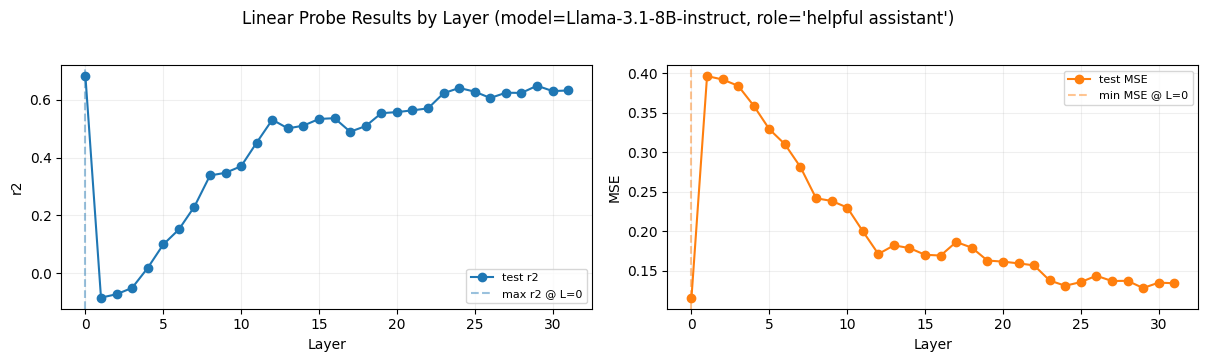

In [41]:
results_path = Path(results_path).resolve()
fig, axes, summ = plot_probe_results_file(
    results_path,
    title=f"Linear Probe Results by Layer (model=Llama-3.1-8B-instruct, role='helpful assistant')",
)
plot_png = results_path.with_name(results_path.stem + "_plot.png")
fig.savefig(plot_png, dpi=150, bbox_inches="tight")
print("Saved plot:", plot_png)
print("Best layer (max R² / primary):", summ["best_layer"])
print("Best layer (min test MSE):", summ["best_layer_mse"])

importlib.reload(notebook_runs)
from notebook_runs import (
    rating_pairwise_preference_accuracy
)
out = rating_pairwise_preference_accuracy(
    metadata_jsonl_path= LP_DIR / "results_linear_probes" / "llama-31-8b-instruct" / "linear_probes_llama-31-8b-instruct_pilot_helpful_assistant_metadata.jsonl",
    probe_results_path= LP_DIR / "results_linear_probes" / "llama-31-8b-instruct" / "linear_probes_llama-31-8b-instruct_pilot_helpful_assistant_probe_results_gen_first_utility_all.json",
)
import pprint
pprint.pprint(out)

In [42]:
# --- Full experiment: edit these ---
import sys
from pathlib import Path

import yaml
from transformers import AutoConfig

import importlib
import notebook_runs
importlib.reload(notebook_runs)
from notebook_runs import (
    default_utilities_rel,
    existing_probe_results_path,
    layer_indices,
    plot_probe_results_file,
    run_collect_then_train,
    run_train_only
)

%matplotlib inline

if "MODEL_KEY" not in dir() or "MODELS_PATH" not in dir():
    raise RuntimeError("Run the model setup cell first (MODEL_KEY, MODELS_PATH).")

NOTEBOOK_REPO_ROOT = REPO_ROOT if COLAB_RUNTIME else MODELS_PATH.parent.parent
LP_DIR = NOTEBOOK_REPO_ROOT / "utility_analysis" / "experiments" / "linear_probes"
if str(LP_DIR) not in sys.path:
    sys.path.insert(0, str(LP_DIR))

from IPython.display import display

# All roles in one collect (comma-separated for CLI). Same utilities for every row — merge JSONs if needed.
ROLES_CONFIG_PATH = "../../shared_options/role_sets.yaml"
ROLE_SET = "default"

FULL_SAVE_DIR = f"results_linear_probes/{MODEL_KEY}"
FULL_SAVE_SUFFIX = f"{MODEL_KEY}_full_multirole"
OPTIONS_REL = "../../shared_options/options_custom.json"
# Path relative to experiments/linear_probes/: must list every option id used by options JSON.
FULL_UTILITIES_DIR = "../../shared_utilities/options_custom/llama-31-8b-instruct"

MAX_EXAMPLES = 0  # 0 = all (role × option) rows
MAX_MODEL_LEN = 1024
BACKEND = "vllm"
VLLM_NO_COMPILE = False
VLLM_ATTENTION_BACKEND = None

POSITION = "gen_first"
TARGET = "utility"
TEST_FRACTION = 0.2
SEED = 42
RIDGE_LAMBDA = 1.0

models_cfg = yaml.safe_load(MODELS_PATH.read_text())
model_entry = models_cfg[MODEL_KEY]
model_path = model_entry.get("path") or model_entry.get("model_name")
cfg = AutoConfig.from_pretrained(model_path, trust_remote_code=True)
n_layers = int(cfg.num_hidden_layers)
layers_spec = "23,24,25,26,27,28,29,30,31"

_, path_per_role = run_collect_then_train(
    NOTEBOOK_REPO_ROOT,
    model_key=MODEL_KEY,
    save_dir=FULL_SAVE_DIR,
    save_suffix=FULL_SAVE_SUFFIX,
    options_path=OPTIONS_REL,
    utilities_dir=FULL_UTILITIES_DIR,
    roles_config_path=ROLES_CONFIG_PATH,
    roleset=ROLE_SET,
    layers=layers_spec,
    max_new_tokens_for_parsing=2,
    max_model_len=MAX_MODEL_LEN,
    max_examples=MAX_EXAMPLES,
    backend=BACKEND,
    position=POSITION,
    target=TARGET,
    probe_mode="per_role",
    test_fraction=TEST_FRACTION,
    seed=SEED,
    ridge_lambda=RIDGE_LAMBDA,
    trust_remote_code=True,
    force_cpu=False,
    hf_fp16_cuda=True,
    hf_bnb_8bit=True,
    vllm_no_compile=VLLM_NO_COMPILE,
    vllm_attention_backend=VLLM_ATTENTION_BACKEND,
)
print("per_role metrics:", path_per_role)

path_cross = run_train_only(
    NOTEBOOK_REPO_ROOT,
    model_key=MODEL_KEY,
    save_dir=FULL_SAVE_DIR,
    save_suffix=FULL_SAVE_SUFFIX,
    position=POSITION,
    target=TARGET,
    probe_mode="cross_role",
    test_fraction=TEST_FRACTION,
    seed=SEED,
    ridge_lambda=RIDGE_LAMBDA,
)
print("cross_role metrics:", path_cross)

Running: /usr/bin/python3 -u /content/llm_preferences/utility_analysis/experiments/linear_probes/run_linear_probes.py --model_key llama-31-8b-instruct --stage collect --backend vllm --save_dir results_linear_probes/llama-31-8b-instruct --save_suffix llama-31-8b-instruct_full_multirole --options_path ../../shared_options/options_custom.json --utilities_dir ../../shared_utilities/options_custom/llama-31-8b-instruct --roleset default --roles_config_path ../../shared_options/role_sets.yaml --layers 23,24,25,26,27,28,29,30,31 --max_new_tokens_for_parsing 2 --max_model_len 1024 --max_examples 0 --trust_remote_code
[collect:debug] ========== linear_probes collect ==========
[collect:debug] pid=12392 cwd=/content/llm_preferences/utility_analysis/experiments/linear_probes
[collect:debug] torch=2.10.0+cu128 cuda_available=True
[collect:debug] cuda_device_count=1
[collect:debug] model_path=/content/models/llama-31-8b-instruct
[collect:debug] tokenizer_path=/content/models/llama-31-8b-instruct
[co

2026-04-14 12:39:57.231910: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-14 12:39:57.251368: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776170397.275766   12392 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776170397.282905   12392 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776170397.300435   12392 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Running: /usr/bin/python3 -u /content/llm_preferences/utility_analysis/experiments/linear_probes/run_linear_probes.py --model_key llama-31-8b-instruct --stage train --save_dir results_linear_probes/llama-31-8b-instruct --save_suffix llama-31-8b-instruct_full_multirole --position gen_first --target utility --probe_mode per_role --test_fraction 0.2 --ridge_lambda 1.0 --seed 42
[train] wrote probe metrics to results_linear_probes/llama-31-8b-instruct/linear_probes_llama-31-8b-instruct_full_multirole_probe_results_gen_first_utility_per_role.json


2026-04-14 12:43:30.781876: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-14 12:43:30.800263: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776170610.824411   13531 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776170610.831611   13531 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776170610.848635   13531 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

per_role metrics: /content/llm_preferences/utility_analysis/experiments/linear_probes/results_linear_probes/llama-31-8b-instruct/linear_probes_llama-31-8b-instruct_full_multirole_probe_results_gen_first_utility_per_role.json
Running: /usr/bin/python3 -u /content/llm_preferences/utility_analysis/experiments/linear_probes/run_linear_probes.py --model_key llama-31-8b-instruct --stage train --save_dir results_linear_probes/llama-31-8b-instruct --save_suffix llama-31-8b-instruct_full_multirole --position gen_first --target utility --probe_mode cross_role --test_fraction 0.2 --ridge_lambda 1.0 --seed 42
[train] wrote probe metrics to results_linear_probes/llama-31-8b-instruct/linear_probes_llama-31-8b-instruct_full_multirole_probe_results_gen_first_utility_cross_role.json


2026-04-14 12:46:30.689105: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-14 12:46:30.707763: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776170790.732631   14363 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776170790.739884   14363 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776170790.757098   14363 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

cross_role metrics: /content/llm_preferences/utility_analysis/experiments/linear_probes/results_linear_probes/llama-31-8b-instruct/linear_probes_llama-31-8b-instruct_full_multirole_probe_results_gen_first_utility_cross_role.json


Using chosen layer: 29 (global best in-distribution, metric=pairwise_pref_acc)
Saved: /content/llm_preferences/utility_analysis/experiments/linear_probes/results_linear_probes/llama-31-8b-instruct/linear_probes_llama-31-8b-instruct_full_multirole_probe_results_gen_first_utility_cross_role_pairwise_pref_acc_heatmap.png
Saved: /content/llm_preferences/utility_analysis/experiments/linear_probes/results_linear_probes/llama-31-8b-instruct/linear_probes_llama-31-8b-instruct_full_multirole_probe_results_gen_first_utility_cross_role_utility_similarity_heatmap.png
Saved: /content/llm_preferences/utility_analysis/experiments/linear_probes/results_linear_probes/llama-31-8b-instruct/linear_probes_llama-31-8b-instruct_full_multirole_probe_results_gen_first_utility_cross_role_utility_sim_vs_cross_gen.png


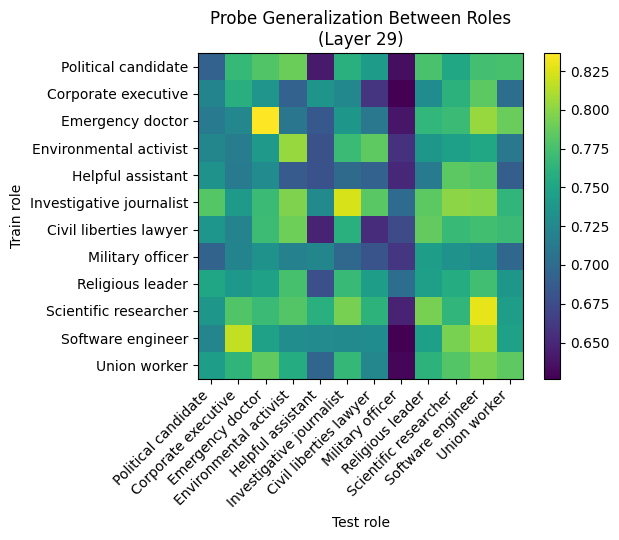

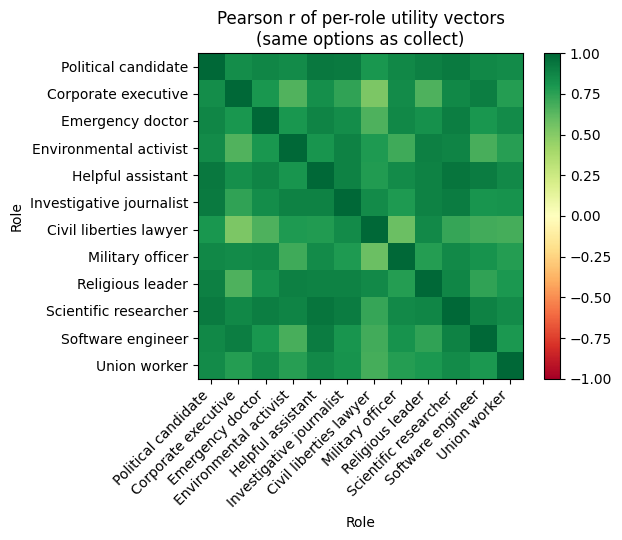

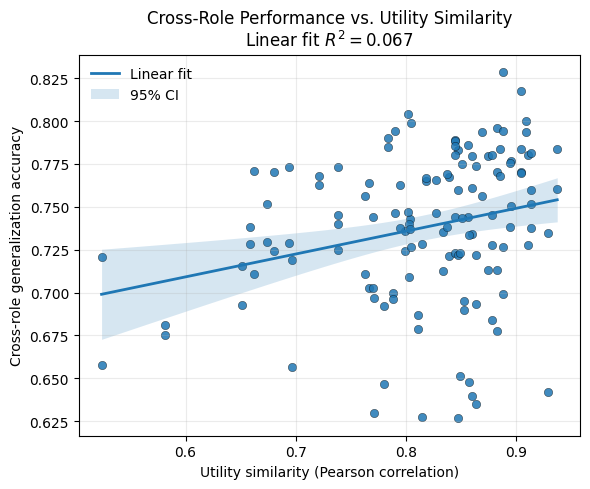

In [47]:
import sys
from pathlib import Path
NOTEBOOK_REPO_ROOT = Path("/content/llm_preferences")
MODEL_KEY = "llama-31-8b-instruct"
OPTIONS_REL = "../../shared_options/options_custom.json"
LP_DIR = NOTEBOOK_REPO_ROOT / "utility_analysis" / "experiments" / "linear_probes"
if str(LP_DIR) not in sys.path:
    sys.path.insert(0, str(LP_DIR))

import importlib
import notebook_runs
importlib.reload(notebook_runs)
from notebook_runs import (
    plot_cross_role_generalization_and_utility,
)

path_cross = LP_DIR / "results_linear_probes" / "llama-31-8b-instruct" / "linear_probes_llama-31-8b-instruct_full_multirole_probe_results_gen_first_utility_cross_role.json"

fig_h1, fig_h2, fig_sc, _info = plot_cross_role_generalization_and_utility(
    path_cross,
    repo_root=NOTEBOOK_REPO_ROOT,
    model_key=MODEL_KEY,
    options_rel=OPTIONS_REL,
    layer=None,
    gen_metric="pairwise_pref_acc",
    similarity_metric="correlation",
    best_layer_global_in_distribution=True
)
stem = path_cross.stem
for fig, suf in [
    (fig_h1, "_pairwise_pref_acc_heatmap.png"),
    (fig_h2, "_utility_similarity_heatmap.png"),
    (fig_sc, "_utility_sim_vs_cross_gen.png"),
]:
    outp = path_cross.with_name(stem + suf)
    fig.savefig(outp, dpi=150, bbox_inches="tight")
    print("Saved:", outp)

In [51]:
import importlib
import notebook_runs
importlib.reload(notebook_runs)
from notebook_runs import (
    compute_cross_role_activation_similarity_results,
)
path_cross = LP_DIR / "results_linear_probes" / "llama-31-8b-instruct/linear_probes_llama-31-8b-instruct_full_multirole_probe_results_gen_first_utility_cross_role.json"

res_path = compute_cross_role_activation_similarity_results(
    cross_role_results_path=path_cross,
    layer=29,
)

Using chosen layer: 29 (activation-similarity compute)
Wrote activation similarity results: /content/llm_preferences/utility_analysis/experiments/linear_probes/results_linear_probes/llama-31-8b-instruct/linear_probes_llama-31-8b-instruct_full_multirole_activation_similarity_layer_29.json


Using chosen layer: 29 (activation-similarity compute)
Wrote activation similarity results: /content/llm_preferences/utility_analysis/experiments/linear_probes/results_linear_probes/llama-31-8b-instruct/linear_probes_llama-31-8b-instruct_full_multirole_activation_similarity_layer_29.json
Using chosen layer: 29 (activation-similarity compute)
Wrote activation similarity results: /content/llm_preferences/utility_analysis/experiments/linear_probes/results_linear_probes/llama-31-8b-instruct/linear_probes_llama-31-8b-instruct_full_multirole_activation_similarity_layer_29.json


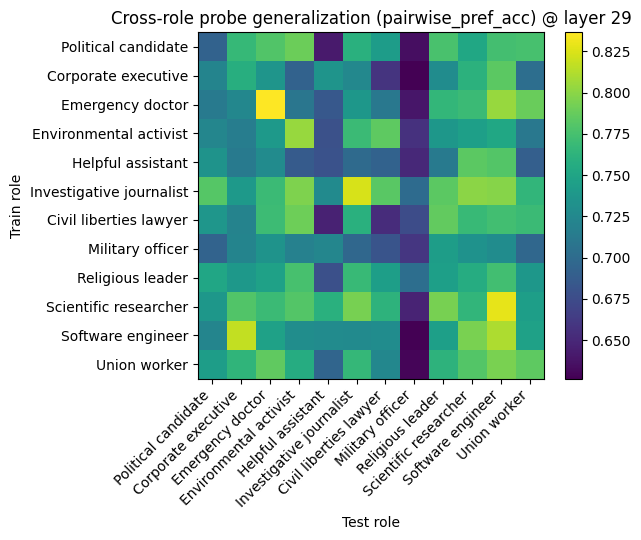

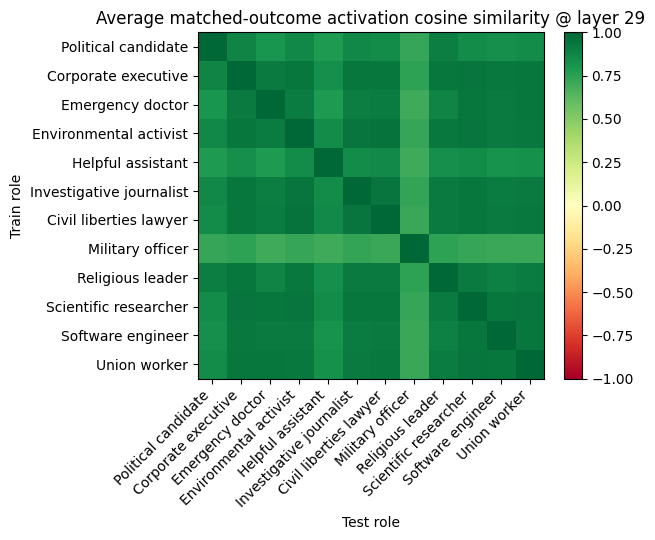

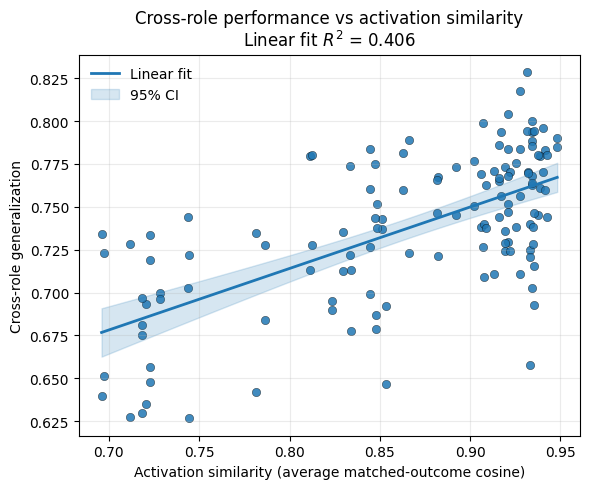

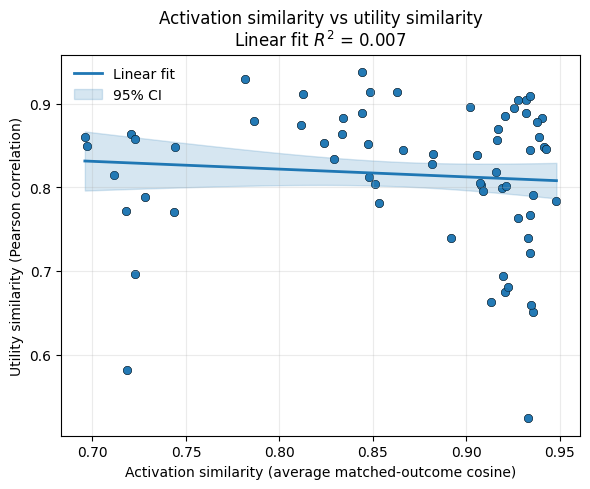

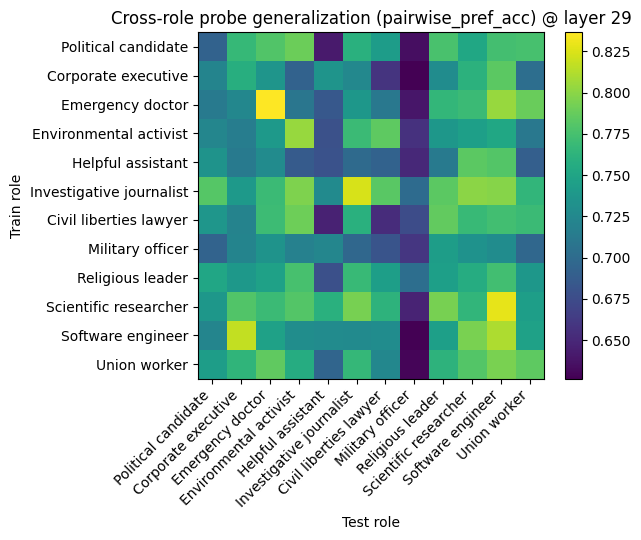

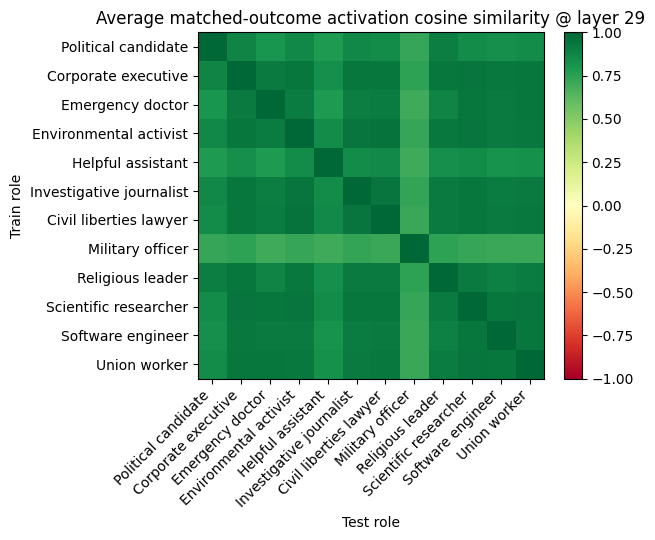

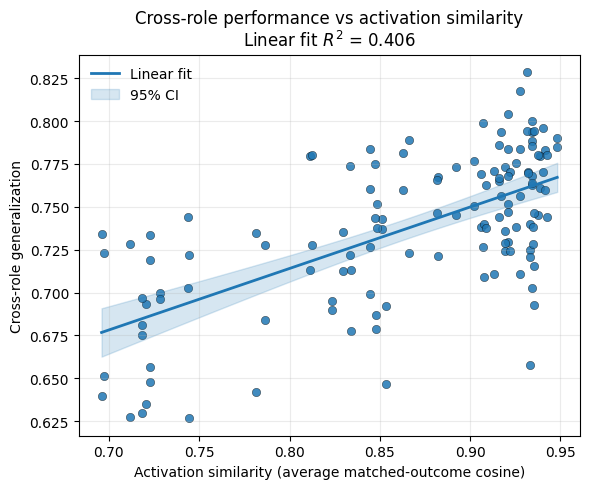

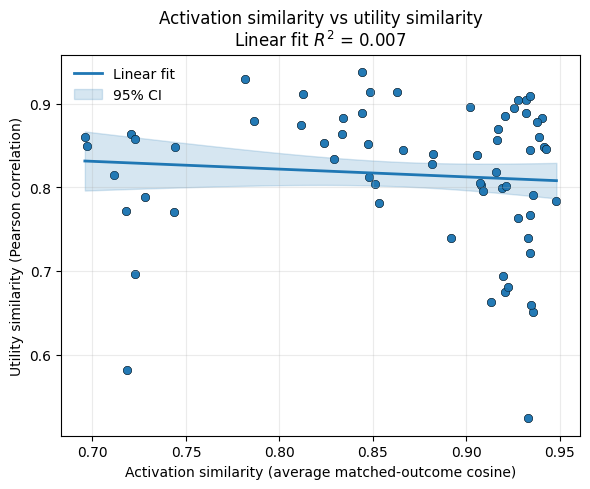

In [52]:
from notebook_runs import (
    plot_cross_role_generalization_and_activation_similarity,
)
fig1, fig2, fig3, fig4, info = plot_cross_role_generalization_and_activation_similarity(
    cross_role_results_path=path_cross,
    layer=29,
    activation_similarity_results_path=res_path,
    gen_metric="pairwise_pref_acc",   # or mse/spearman/pairwise_pref_acc
)
fig1, fig2, fig3, fig4, info = plot_cross_role_generalization_and_activation_similarity(
    cross_role_results_path=path_cross,
    layer=29,
    activation_similarity_results_path=res_path,
    gen_metric="pairwise_pref_acc",   # or mse/spearman/pairwise_pref_acc
)

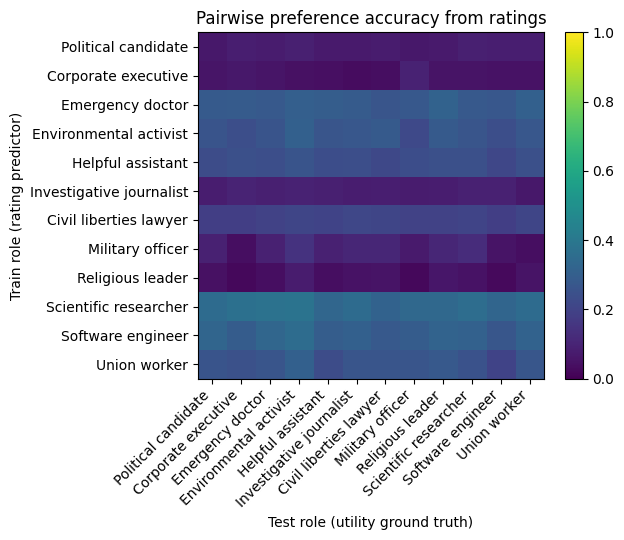

In [57]:
import importlib
import notebook_runs
importlib.reload(notebook_runs)
from notebook_runs import (
    plot_cross_role_generalization_and_utility,
)

from notebook_runs import (
    plot_rating_pairwise_preference_heatmap,
)

fig, info = plot_rating_pairwise_preference_heatmap(
    metadata_jsonl_path=LP_DIR / "results_linear_probes" / "llama-31-8b-instruct" / "linear_probes_llama-31-8b-instruct_full_multirole_metadata.jsonl",
)

In [58]:
import shutil
from pathlib import Path

source_dir = LP_DIR / "results_linear_probes"
zip_name = "results_linear_probes_part2"
drive_dest = Path("/content/drive/MyDrive")
zip_path = Path(f"/content/{zip_name}")

shutil.make_archive(zip_path, 'zip', source_dir)
shutil.copy(f"{zip_path}.zip", drive_dest)

print(f"Saved to {drive_dest}/{zip_name}.zip")

Saved to /content/drive/MyDrive/results_linear_probes_part2.zip
